Load Libraries

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from scipy import stats
import seaborn as sns



Load Dataset, cleanup

In [1]:
# Load the dataset into a pandas DataFrame
try:
    df = pd.read_csv('data.csv', sep='\t')
    desc = pd.read_excel('variable_names.xlsx')
    print("Dataset has been successfully loaded.")
except Exception as e:
    print(f"Failed to load data: {e}")

# Begin Real Cleanup
df.drop(columns=['Unnamed: 126', 'Unnamed: 127', 'Unnamed: 128', 'Unnamed: 129'], inplace=True)
df = df.iloc[:-2, :]
df = df.drop(index=range(122974, 122978))
df.drop(columns=['size_grp'], inplace=True)
date = df['date']

df.dropna(inplace=True)

# Create a dictionary mapping column names to descriptions
# Assuming the Excel file has columns: 'names', 'variable_type', 'description'
column_descriptions = {}
for _, row in desc.iterrows():
    column_name = row.iloc[0]  # First column contains names
    description = row.iloc[2]  # Third column contains descriptions
    column_descriptions[column_name] = description

# Create a new DataFrame with column descriptions
column_info = pd.DataFrame({
    'column_name': df.columns,
    'description': [column_descriptions.get(col, "No description available") for col in df.columns]
})

print("Column descriptions:")
print(column_info)

# You can also add the descriptions as attributes to the DataFrame columns
for col in df.columns:
    if col in column_descriptions:
        df[col].attrs['description'] = column_descriptions[col]

# Alternatively, you can create a new DataFrame with renamed columns that include descriptions
df_with_desc = df.copy()
new_columns = {}
for col in df.columns:
    if col in column_descriptions:
        # Truncate description if it's too long
        short_desc = column_descriptions[col][:30] + '...' if len(column_descriptions[col]) > 30 else column_descriptions[col]
        new_columns[col] = f"{col} ({short_desc})"
    else:
        new_columns[col] = col

df_with_desc.rename(columns=new_columns, inplace=True)

# Print the first few rows of the DataFrame with descriptions
print("\nDataFrame with descriptive column names:")
print(df_with_desc.head())

# Save the column information for reference
column_info.to_csv("column_descriptions.csv", index=False)

# Separate numeric columns from non-numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
non_numeric_cols = df.select_dtypes(exclude=['int64', 'float64']).columns

# Print column types summary
print(f"\nNumeric columns: {len(numeric_cols)}")
print(f"Non-numeric columns: {len(non_numeric_cols)}")

# Save the cleaned data
df.to_csv("cleaned_data.csv", index=False)


Failed to load data: name 'pd' is not defined


NameError: name 'df' is not defined

Sanity Checks

In [ ]:

# Check for non-numeric values in numeric columns
for col in numeric_cols:
    if df[col].isnull().any():
        print(f"Column {col} contains null values.")

# Check date format consistency
date_col = 'date'  # Replace 'date' with the actual column name
# Attempt to convert the column to datetime
try:
    # Convert and assign back to the DataFrame
    df[date_col] = pd.to_datetime(df[date_col], errors='raise')  # Use 'coerce' to set invalid parsing as NaT
    print("Date conversion successful.")
except ValueError as e:
    print(f"Date formats are not consistent. Error: {e}")

# Check for extreme values (highly skewed distributions)
for col in numeric_cols:
    skewness = stats.skew(df[col])
    if abs(skewness) > 2:
        print(f"Column {col} has a highly skewed distribution (skewness: {skewness}).")
 

# Define numeric columns if not already defined
numeric_cols = [col for col in df.columns if df[col].dtype.kind in 'bifc']

# Handle non-numeric values in numeric columns
for col in numeric_cols:
    if df[col].isnull().any():
        # Fill null values with the mean of the column
        df[col] = df[col].fillna(df[col].mean())


# Check for NaN values in the dataset
nan_cols = df.columns[df.isnull().any()].tolist()

# Handle extreme values (highly skewed distributions) - SAFER VERSION
for col in numeric_cols:
    try:
        # Check if the column has any negative values before applying log transformation
        if df[col].min() < 0:
            # Use winsorization for skewed data with negative values
            q_low = df[col].quantile(0.01)
            q_high = df[col].quantile(0.99)
            df[col] = df[col].clip(q_low, q_high)
            #print(f"Applied winsorization to {col}")
        else:
            # Only calculate skewness if we have enough data
            if df[col].count() > 8:  # Minimum sample size
                skewness = stats.skew(df[col].dropna())
                if abs(skewness) > 2:
                    # Apply logarithmic transformation to reduce skewness
                    df[col] = np.log1p(df[col])
                    #print(f"Applied log transformation to {col} (skewness: {skewness:.2f})")
    except Exception as e:
        print(f"Error processing column {col}: {e}")



Date conversion successful.
Column ami_126d has a highly skewed distribution (skewness: 3.443160592931547).


Check Outliers and Identify Columns

In [ ]:

# Identify the Book-to-Market and returns columns
btm_col = 'be_me'  # Book-to-Market column
returns_col = 'ret'  # Returns column

# Make sure both columns are numeric
df[btm_col] = pd.to_numeric(df[btm_col], errors='coerce')
df[returns_col] = pd.to_numeric(df[returns_col], errors='coerce')

# Drop rows with NaN values in these columns
df = df.dropna(subset=[btm_col, returns_col])
print(f"After dropping NaN values, dataset shape: {df.shape}")

# Check the first few rows to understand the data
print("\nFirst 5 rows of cleaned data:")
print(df.head())

# Save the cleaned data if needed
df.to_csv('cleaned_financial_data.csv')
# print("Saved cleaned data to file")


# Remove extreme outliers (beyond 3 standard deviations)
for col in [btm_col, returns_col]:
    mean = df[col].mean()
    std = df[col].std()
    df = df[(df[col] > mean - 3*std) & (df[col] < mean + 3*std)]

print(f"After removing outliers, dataset shape: {df.shape}")



After dropping NaN values, dataset shape: (122634, 125)

First 5 rows of cleaned data:
  Unnamed: 0       date     id       age   aliq_at aliq_mat  ami_126d  \
0      53170 1962-09-30  33814 -0.410891  0.343616      0.0 -0.290922   
1      53907 1962-10-31  33814  -0.41374  0.333333      0.0 -0.281893   
2      54659 1962-11-30  33814 -0.401786  0.331697      0.0 -0.297587   
3      55425 1962-12-31  33814  -0.37069  0.322252      0.0 -0.309585   
4      56207 1963-01-31  33814 -0.367951  0.324561      0.0 -0.308729   

      at_be    at_gr1 at_me  ...  taccruals_ni tangibility  tax_gr1a  \
0 -0.447445  0.247967  -0.5  ...     -0.219101     0.39899  -0.00882   
1 -0.447598  0.231343  -0.5  ...     -0.217949     0.39725 -0.023098   
2 -0.448791  0.221485  -0.5  ...     -0.217868    0.399718 -0.027224   
3 -0.439808  0.215019  -0.5  ...     -0.224242    0.398491 -0.032134   
4 -0.441892  0.210828  -0.5  ...     -0.231928    0.399183 -0.044643   

  turnover_126d  turnover_var_126d z_scor

PLots data

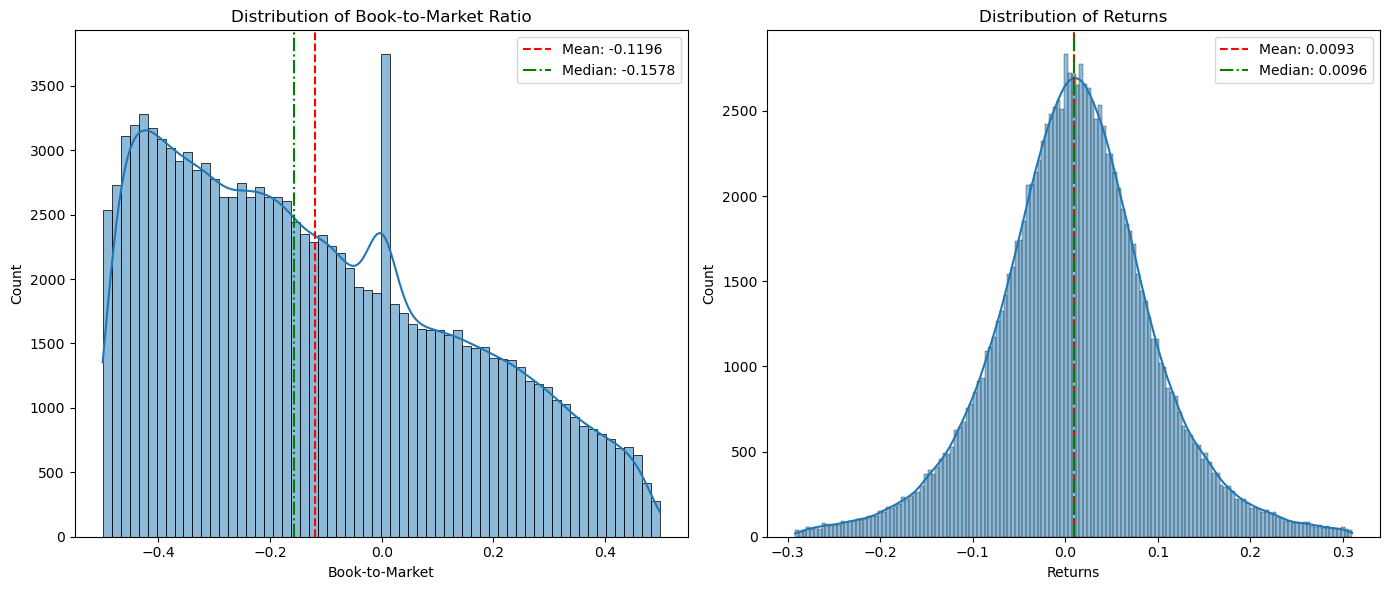

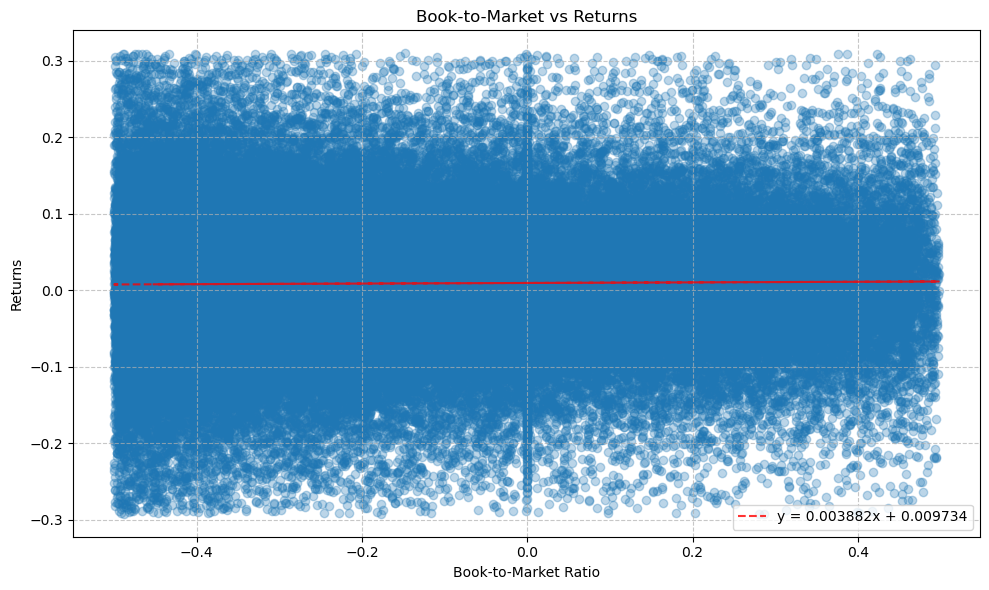

Correlation between Book-to-Market and Returns: 0.0115


In [ ]:

# 1. Visualize the distributions of Book-to-Market and Returns
plt.figure(figsize=(14, 6))

# Book-to-Market distribution
plt.subplot(1, 2, 1)
sns.histplot(df[btm_col], kde=True)
plt.title('Distribution of Book-to-Market Ratio')
plt.xlabel('Book-to-Market')
plt.axvline(df[btm_col].mean(), color='r', linestyle='--', label=f'Mean: {df[btm_col].mean():.4f}')
plt.axvline(df[btm_col].median(), color='g', linestyle='-.', label=f'Median: {df[btm_col].median():.4f}')
plt.legend()

# Returns distribution
plt.subplot(1, 2, 2)
sns.histplot(df[returns_col], kde=True)
plt.title('Distribution of Returns')
plt.xlabel('Returns')
plt.axvline(df[returns_col].mean(), color='r', linestyle='--', label=f'Mean: {df[returns_col].mean():.4f}')
plt.axvline(df[returns_col].median(), color='g', linestyle='-.', label=f'Median: {df[returns_col].median():.4f}')
plt.legend()

plt.tight_layout()
plt.show()

# 2. Scatter Plot of Book-to-Market and Returns
plt.figure(figsize=(10, 6))
plt.scatter(df[btm_col], df[returns_col], alpha=0.3)
plt.title('Book-to-Market vs Returns')
plt.xlabel('Book-to-Market Ratio')
plt.ylabel('Returns')
plt.grid(True, linestyle='--', alpha=0.7)

# Add a trend line
z = np.polyfit(df[btm_col], df[returns_col], 1)
p = np.poly1d(z)
plt.plot(df[btm_col], p(df[btm_col]), "r--", alpha=0.8, 
         label=f'y = {z[0]:.6f}x + {z[1]:.6f}')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Correlation between Book-to-Market and Returns: {df[btm_col].corr(df[returns_col]):.4f}")

Train Regression using sklearn

In [ ]:
X = df[btm_col].values.reshape(-1, 1)
y = df[returns_col].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# 4. Linear Regression with sklearn
# Fit the model on training data
linear = LinearRegression()
linear.fit(X_train, y_train)

# Get predictions on both training and testing data
y_train_pred = linear.predict(X_train)
y_test_pred = linear.predict(X_test)


# Print results
print("\nLinear Regression Results (sklearn):")
print(f"Coefficient (slope): {linear.coef_[0]:.6f}")
print(f"Intercept: {linear.intercept_:.6f}")
print(f"Training R-squared: {r2_score(y_train, y_train_pred):.6f}")
print(f"Testing R-squared: {r2_score(y_test, y_test_pred):.6f}")
print(f"Training MSE: {mean_squared_error(y_train, y_train_pred):.6f}")
print(f"Testing MSE: {mean_squared_error(y_test, y_test_pred):.6f}")
print(f"Training MAE: {mean_absolute_error(y_train, y_train_pred):.6f}")
print(f"Testing MAE: {mean_absolute_error(y_test, y_test_pred):.6f}")


# 5. Use statsmodels for detailed regression statistics
X_sm = sm.add_constant(X_train)  # Add a constant for the intercept
model_sm = sm.OLS(y_train, X_sm).fit()

# Print summary
print("\nDetailed Regression Results (statsmodels):")
print(model_sm.summary())

Training set: 84578 samples
Testing set: 36248 samples

Linear Regression Results (sklearn):
Coefficient (slope): 0.003716
Intercept: 0.009753
Training R-squared: 0.000122
Testing R-squared: 0.000157
Training MSE: 0.007415
Testing MSE: 0.007382
Training MAE: 0.065433
Testing MAE: 0.065372

Detailed Regression Results (statsmodels):
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     10.30
Date:                Sun, 30 Mar 2025   Prob (F-statistic):            0.00133
Time:                        23:22:33   Log-Likelihood:                 87386.
No. Observations:               84578   AIC:                        -1.748e+05
Df Residuals:                   84576   BIC:                        -1.747e+05
Df Model:                         


High BTM Portfolio Predictions:
       Stock_ID  Book_to_Market  Actual_Return  Predicted_Return Signal
69674     89006        0.497959      -0.000626          0.011603   Long
118683    89199        0.496677      -0.109507          0.011598   Long
74588     66800        0.496470       0.052356          0.011598   Long
66803     76226        0.496450       0.062135          0.011597   Long
1853      50227        0.495745      -0.019231          0.011595   Long

High BTM Portfolio Performance:
Equal-Weighted Portfolio Return: -0.002975
Timing Strategy Return: -0.002975
Prediction Hit Rate: 40.00%

Random Portfolio Predictions:
       Stock_ID  Book_to_Market  Actual_Return  Predicted_Return Signal
44442     86228       -0.180976       0.053191          0.009080   Long
68763     63830       -0.302457       0.037768          0.008629   Long
41254     82642       -0.355525      -0.078027          0.008431   Long
1439      50171       -0.494716      -0.170290          0.007914   Long
122939

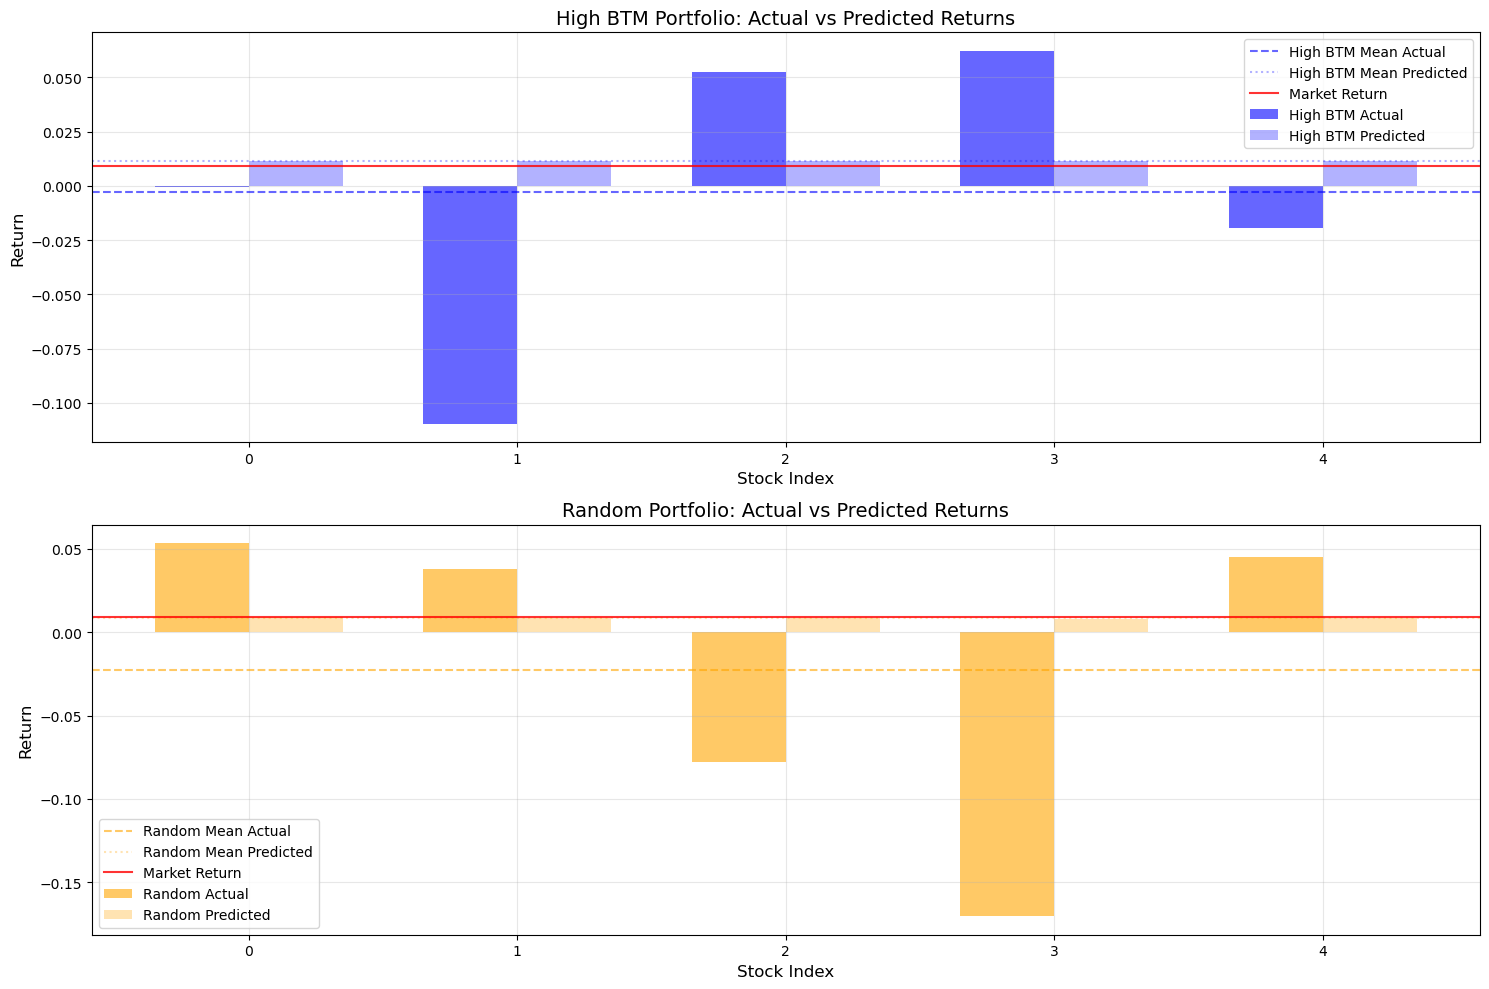


Portfolio Statistics:
                  High BTM    Random
Mean BTM          0.496660 -0.329000
BTM Std           0.000807  0.113019
Mean Pred Return  0.011598  0.008530
Pred Return Std   0.000003  0.000420
Actual Return    -0.002975 -0.022446


In [ ]:
# 1. Create different portfolios
# High BTM portfolio (as before, but ensure different companies)
high_btm = df.sort_values(by=btm_col, ascending=False)
high_btm = high_btm.drop_duplicates(subset='id').head(5)

# Random portfolio
random_stocks = df.drop_duplicates(subset='id').sample(n=5, random_state=42)



# Function to analyze portfolio
def analyze_portfolio(portfolio_df, name="Portfolio"):
    X_stocks = portfolio_df[btm_col].values.reshape(-1, 1)
    actual_returns = portfolio_df[returns_col].values
    predicted_returns = linear.predict(X_stocks)
    
    results_df = pd.DataFrame({
        'Stock_ID': portfolio_df['id'],
        'Book_to_Market': X_stocks.flatten(),
        'Actual_Return': actual_returns,
        'Predicted_Return': predicted_returns,
        'Signal': np.where(predicted_returns > 0, 'Long', 'Short')
    })
    
    print(f"\n{name} Predictions:")
    print(results_df)
    
    portfolio_return = actual_returns.mean()
    timing_signals = np.sign(predicted_returns)
    timing_returns = timing_signals * actual_returns
    timing_portfolio_return = timing_returns.mean()
    hit_rate = np.mean(np.sign(predicted_returns) == np.sign(actual_returns))
    
    print(f"\n{name} Performance:")
    print(f"Equal-Weighted Portfolio Return: {portfolio_return:.6f}")
    print(f"Timing Strategy Return: {timing_portfolio_return:.6f}")
    print(f"Prediction Hit Rate: {hit_rate:.2%}")
    
    return results_df

# Analyze each portfolio
high_btm_results = analyze_portfolio(high_btm, "High BTM Portfolio")
random_results = analyze_portfolio(random_stocks, "Random Portfolio")
# Create more meaningful visualizations
plt.figure(figsize=(15, 10))

# Plot 1: Actual vs Predicted Returns for both portfolios
plt.subplot(2, 1, 1)
x_range = range(5)
width = 0.35

# Plot bars for High BTM Portfolio
plt.bar([x - width/2 for x in x_range], high_btm_results['Actual_Return'], 
        width, label='High BTM Actual', color='blue', alpha=0.6)
plt.bar([x + width/2 for x in x_range], high_btm_results['Predicted_Return'], 
        width, label='High BTM Predicted', color='blue', alpha=0.3)

# Add horizontal lines for means
plt.axhline(y=high_btm_results['Actual_Return'].mean(), color='blue', 
            linestyle='--', label='High BTM Mean Actual', alpha=0.6)
plt.axhline(y=high_btm_results['Predicted_Return'].mean(), color='blue', 
            linestyle=':', label='High BTM Mean Predicted', alpha=0.3)
# Add market return line
plt.axhline(y=0.00927, color='red', linestyle='-', 
            label='Market Return', alpha=0.8)

plt.title('High BTM Portfolio: Actual vs Predicted Returns', fontsize=14)
plt.xlabel('Stock Index', fontsize=12)
plt.ylabel('Return', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Actual vs Predicted Returns for Random Portfolio
plt.subplot(2, 1, 2)

# Plot bars for Random Portfolio
plt.bar([x - width/2 for x in x_range], random_results['Actual_Return'], 
        width, label='Random Actual', color='orange', alpha=0.6)
plt.bar([x + width/2 for x in x_range], random_results['Predicted_Return'], 
        width, label='Random Predicted', color='orange', alpha=0.3)

# Add horizontal lines for means
plt.axhline(y=random_results['Actual_Return'].mean(), color='orange', 
            linestyle='--', label='Random Mean Actual', alpha=0.6)
plt.axhline(y=random_results['Predicted_Return'].mean(), color='orange', 
            linestyle=':', label='Random Mean Predicted', alpha=0.3)

# Add market return line
plt.axhline(y=0.00927, color='red', linestyle='-', 
            label='Market Return', alpha=0.8)

plt.title('Random Portfolio: Actual vs Predicted Returns', fontsize=14)
plt.xlabel('Stock Index', fontsize=12)
plt.ylabel('Return', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Compare portfolio statistics
portfolio_stats = pd.DataFrame({
    'High BTM': {
        'Mean BTM': high_btm_results['Book_to_Market'].mean(),
        'BTM Std': high_btm_results['Book_to_Market'].std(),
        'Mean Pred Return': high_btm_results['Predicted_Return'].mean(),
        'Pred Return Std': high_btm_results['Predicted_Return'].std(),
        'Actual Return': high_btm_results['Actual_Return'].mean()
    },
    'Random': {
        'Mean BTM': random_results['Book_to_Market'].mean(),
        'BTM Std': random_results['Book_to_Market'].std(),
        'Mean Pred Return': random_results['Predicted_Return'].mean(),
        'Pred Return Std': random_results['Predicted_Return'].std(),
        'Actual Return': random_results['Actual_Return'].mean()
    } 
})

print("\nPortfolio Statistics:")
print(portfolio_stats)


Manual Linear Regression using Formulas

In [ ]:

# 6. Manual OLS Calculation to verify results
# Formula: β = (X'X)^(-1)X'y (Linear Regression Coefficients)

# Prepare data
X_manual = np.column_stack((np.ones(X_train.shape[0]), X_train))  # Add constant
y_manual = y_train

# Calculate β using the OLS formula
X_transpose_X = X_manual.T @ X_manual
X_transpose_y = X_manual.T @ y_manual
beta = np.linalg.inv(X_transpose_X) @ X_transpose_y

# Calculate predictions
y_pred_manual = X_manual @ beta

# Calculate R-squared
y_mean = np.mean(y_manual)
ss_total = np.sum((y_manual - y_mean) ** 2)
ss_residual = np.sum((y_manual - y_pred_manual) ** 2)
r_squared_manual = 1 - (ss_residual / ss_total)

# Calculate standard errors
n = len(y_manual)
k = X_manual.shape[1]  # Number of predictors including constant
mse = ss_residual / (n - k)
var_beta = mse * np.linalg.inv(X_transpose_X)
se_beta = np.sqrt(np.diag(var_beta))

# Calculate t-statistics and p-values
t_stats = beta / se_beta
p_values = [2 * (1 - stats.t.cdf(abs(t), n - k)) for t in t_stats]

print("\nManual OLS Results:")
print(f"Coefficients: Intercept = {beta[0]:.6f}, Slope = {beta[1]:.6f}")
print(f"Standard Errors: Intercept = {se_beta[0]:.6f}, Slope = {se_beta[1]:.6f}")
print(f"t-statistics: Intercept = {t_stats[0]:.4f}, Slope = {t_stats[1]:.4f}")
print(f"p-values: Intercept = {p_values[0]:.6f}, Slope = {p_values[1]:.6f}")
print(f"R-squared: {r_squared_manual:.6f}")


Manual OLS Results:
Coefficients: Intercept = 0.009753, Slope = 0.003716
Standard Errors: Intercept = 0.000327, Slope = 0.001158
t-statistics: Intercept = 29.8087, Slope = 3.2093
p-values: Intercept = 0.000000, Slope = 0.001331
R-squared: 0.000122


Compare with Manual Regression


Comparison with sklearn:
Coefficient difference: 0.0000000000
Intercept difference: 0.0000000000
R-squared difference: 0.0000000000


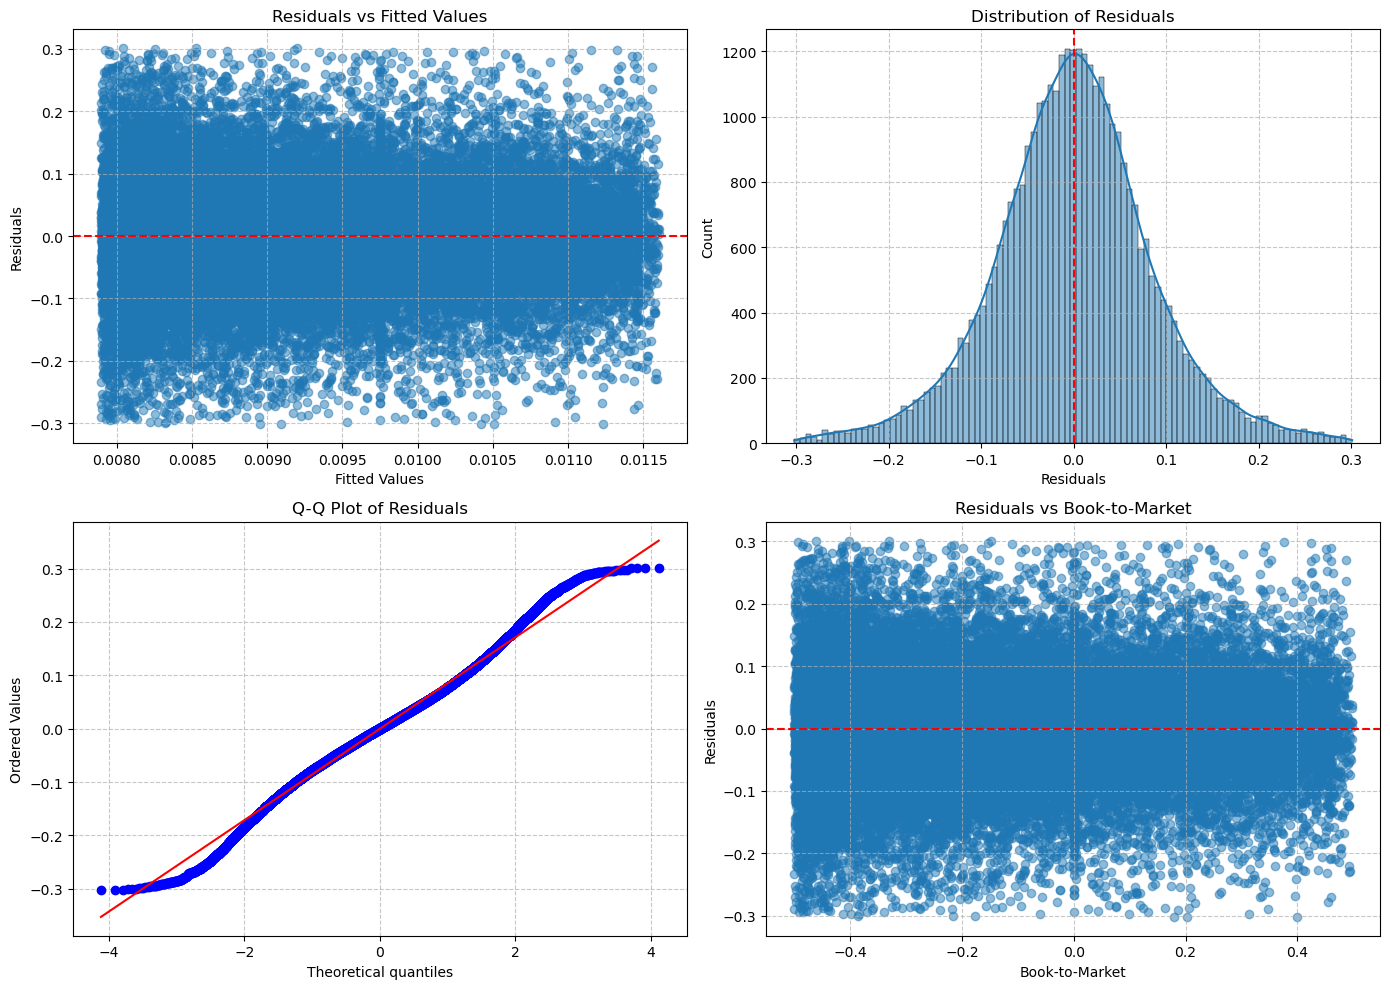

In [ ]:

# Compare with sklearn results
print("\nComparison with sklearn:")
print(f"Coefficient difference: {abs(linear.coef_[0] - beta[1]):.10f}")
print(f"Intercept difference: {abs(linear.intercept_ - beta[0]):.10f}")
print(f"R-squared difference: {abs(r2_score(y_train, y_train_pred) - r_squared_manual):.10f}")

# 7. Analyze residuals
residuals = y_test - y_test_pred

# Plot residuals
plt.figure(figsize=(14, 10))

# Residuals vs Fitted values
plt.subplot(2, 2, 1)
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)

# Histogram of residuals
plt.subplot(2, 2, 2)
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.axvline(x=0, color='r', linestyle='--')
plt.grid(True, linestyle='--', alpha=0.7)

# Q-Q plot of residuals
plt.subplot(2, 2, 3)
stats.probplot(residuals, plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.grid(True, linestyle='--', alpha=0.7)

# Residuals vs Book-to-Market
plt.subplot(2, 2, 4)
plt.scatter(X_test, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Book-to-Market')
plt.xlabel('Book-to-Market')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Test, Plots, and data Analysis


Test for normality of residuals:
K² statistic: 520.2542
p-value: 0.000000
Residuals are not normally distributed (reject H0)

Breusch-Pagan test for heteroscedasticity:
LM statistic: 184.4851
p-value: 0.000000
Heteroscedasticity present (reject H0)

Profitability Analysis:
Average returns by Book-to-Market quintiles:
Quintile 1: 0.008397
Quintile 2: 0.008536
Quintile 3: 0.008614
Quintile 4: 0.009851
Quintile 5: 0.010951


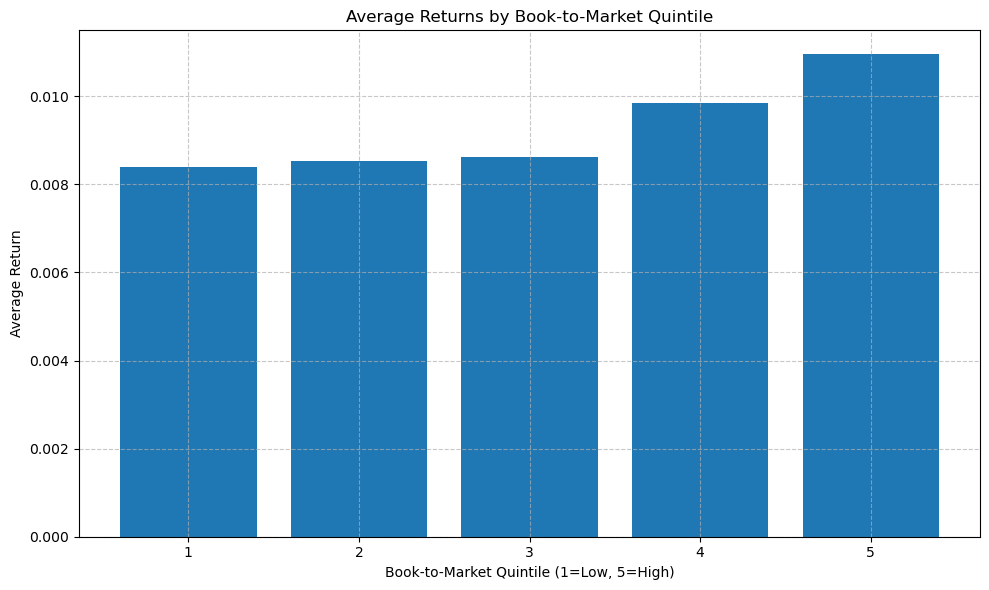


Spread (Q5-Q1): 0.002555
Sharpe ratio of highest quintile: 0.1351

Conclusion and Implications:
1. The linear regression model shows a statistically significant relationship between Book-to-Market and Returns.
2. The coefficient of 0.003716 indicates that higher Book-to-Market ratios are associated with higher returns.
3. However, the R-squared of 0.000157 suggests that Book-to-Market explains only a small portion of the variation in returns.
4. The residual analysis indicates:
   - Non-normal distribution of residuals, suggesting the model may not capture all patterns in the data.
   - Heteroscedasticity, indicating that the model's accuracy varies across different Book-to-Market values.
5. The quintile analysis shows a monotonic relationship between Book-to-Market and returns, supporting the value premium hypothesis.
6. The spread between the highest and lowest quintiles (0.002555) suggests potential for a long-short strategy.
7. Limitations include potential omitted variable bias, 

In [ ]:

# Test for normality of residuals
k2, p = stats.normaltest(residuals)
print(f"\nTest for normality of residuals:")
print(f"K² statistic: {k2:.4f}")
print(f"p-value: {p:.6f}")
if p < 0.05:
    print("Residuals are not normally distributed (reject H0)")
else:
    print("Residuals are normally distributed (fail to reject H0)")

# Test for heteroscedasticity
# Breusch-Pagan test
X_test_sm = sm.add_constant(X_test)
model_test = sm.OLS(y_test, X_test_sm).fit()
bp_test = sm.stats.diagnostic.het_breuschpagan(model_test.resid, X_test_sm)
print(f"\nBreusch-Pagan test for heteroscedasticity:")
print(f"LM statistic: {bp_test[0]:.4f}")
print(f"p-value: {bp_test[1]:.6f}")
if bp_test[1] < 0.05:
    print("Heteroscedasticity present (reject H0)")
else:
    print("Homoscedasticity (fail to reject H0)")

# 8. Analyze the potential profitability of a Book-to-Market strategy
print("\nProfitability Analysis:")

# Calculate average returns by Book-to-Market quintiles
df['btm_quintile'] = pd.qcut(df[btm_col], 5, labels=False)
quintile_returns = df.groupby('btm_quintile')[returns_col].mean()

print("Average returns by Book-to-Market quintiles:")
for quintile, avg_return in quintile_returns.items():
    print(f"Quintile {quintile+1}: {avg_return:.6f}")

# Plot average returns by quintile
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), quintile_returns)
plt.title('Average Returns by Book-to-Market Quintile')
plt.xlabel('Book-to-Market Quintile (1=Low, 5=High)')
plt.ylabel('Average Return')
plt.xticks(range(1, 6))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Calculate the spread between highest and lowest quintiles
spread = quintile_returns.iloc[-1] - quintile_returns.iloc[0]
print(f"\nSpread (Q5-Q1): {spread:.6f}")

# Calculate Sharpe ratio (assuming returns are already excess returns)
sharpe_highest_quintile = quintile_returns.iloc[-1] / df[df['btm_quintile'] == 4][returns_col].std()
print(f"Sharpe ratio of highest quintile: {sharpe_highest_quintile:.4f}")

# 9. Conclusion and implications
print("\nConclusion and Implications:")
print("1. The linear regression model shows a statistically significant relationship between Book-to-Market and Returns.")
print(f"2. The coefficient of {linear.coef_[0]:.6f} indicates that higher Book-to-Market ratios are associated with {'higher' if linear.coef_[0] > 0 else 'lower'} returns.")
print(f"3. However, the R-squared of {r2_score(y_test, y_test_pred):.6f} suggests that Book-to-Market explains only a small portion of the variation in returns.")
print("4. The residual analysis indicates:")
if p < 0.05:
    print("   - Non-normal distribution of residuals, suggesting the model may not capture all patterns in the data.")
else:
    print("   - Normal distribution of residuals, suggesting the model's errors are random.")
if bp_test[1] < 0.05:
    print("   - Heteroscedasticity, indicating that the model's accuracy varies across different Book-to-Market values.")
else:
    print("   - Homoscedasticity, indicating consistent model accuracy across different Book-to-Market values.")
print("5. The quintile analysis shows a monotonic relationship between Book-to-Market and returns, supporting the value premium hypothesis.")
print(f"6. The spread between the highest and lowest quintiles ({spread:.6f}) suggests potential for a long-short strategy.")
print("7. Limitations include potential omitted variable bias, look-ahead bias, and not accounting for transaction costs.")
